## Abstract Qubo Class 

The code is structured so that the two classes `CommunityDetection` and `AssetAllocation` are inherited from the abstract class `Qubo`. The `Qubo` abstract class represents the quadratic unconstrained binary optimization (QUBO) class of problems, and stores functions to solve them. In particular it has the following functions: 

- `build_qubo` takes in the parameters defined in the constructor of the class and creates the QUBO objective matrix which will be fed into the annealer, denoted in the code as `Q`. Since this function is different for community detection and asset allocation it is defined as a `@abstractmethod` in the `Qubo` class. 

- `solve` takes in the type of solver that is to be used to solve the QUBO matrix, in particular one of the following: `"EXACT"`, `"SIMULATED"`, `"HYBRID"` and `"QPU"` to represent exact diagonization (extremely slow), simulated annealing, using D Wave's hybrid solver and using D Wave's quantum annealer respectivly. 

- `decode_solution` this function takes the output of the solver and decodes it depending on the scheme used by the solving algorithm, for instance for asset allocation we decode it using one hot, community detection uses a seperate method. Since this function is different for community detection and asset allocation it is defined as a `@abstractmethod` in the `Qubo` class. 

- `run` is a function that simply runs all of the steps above, it first takes the inputs of the class and with `build_qubo` creates the QUBO objective function, then it solves it with `solve` using the predefined method then finally it decodes the solution using `decode_solution`, and returns the output. This is the only function that the user will call from any of the classes.

Recall that the community detection class takes in the adjacency matrix (`adjacency_matrix`) that is to be used to create the graph and the number of communities (`number_communities`) to create its QUBO objective function (adjacency is used to create the modularity matrix), so these are the only two parameters `CommunityDetection` takes in (alongside some predefined constants in the QUBO objective function). Asset allocation takes in the annulized returns (`returns`) and the covariance matrix `covariance` of the assets the algorithm is to run on to create its QUBO objective function. 

In [1]:
import sys
sys.path.append("..")

from src.modules import *

## Community Asset Allocation Algorithm

Our algorithm combines both community detection, we first start by getting a predefined list of assets, and getting their daily returns. Note that `daily_returns` is the returns for just one work day, in order to extrapolate to an entire year or annulize we multiply by `252`. 

In [2]:
with open("../src/assets.txt", "r") as file:
    assets = [ticker for line in file if (ticker := line.split("#")[0].split("-")[0].split(" ")[0].strip())]
    print(assets)

['AAPL', 'MSFT', 'NVDA', 'ADBE', 'AVGO', 'AMD', 'CRM', 'CSCO', 'ORCL', 'QCOM', 'NOW', 'INTU', 'IBM', 'AMAT', 'MU', 'PANW', 'ACN', 'TXN', 'LRCX', 'KLAC']


In [3]:
daily_returns = closing_prices(assets=assets)
returns = daily_returns.mean() * 252

[*********************100%***********************]  20 of 20 completed


With these returns we can calculate the covarience matrix, which we can use to create the adjacency graph. Note that we create the graph object using `networkx`. 

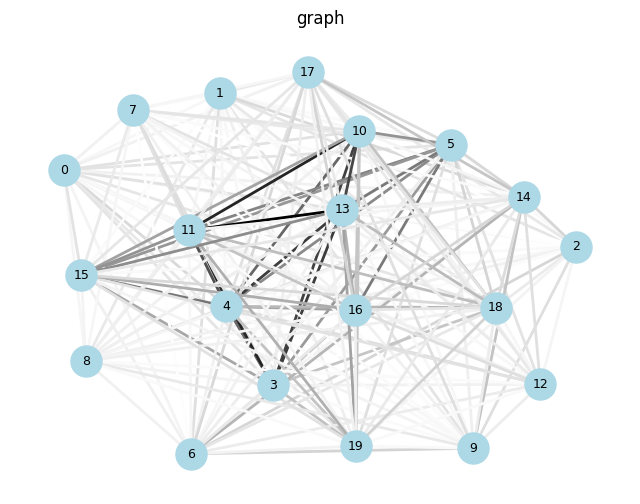

In [4]:
graph_adjacency = get_covariance(daily_returns=daily_returns, zero_diagonal=True)
covariance_matrix = get_covariance(daily_returns=daily_returns, annualize=True)

graph = nx.from_numpy_array(graph_adjacency.to_numpy())
draw_graph(graph=graph)

Now that we have the graph we can now create an instance of `CommunityDetection` to solve a qubo that will give us the communities created from the covariance matrix using the community detection algorithm within the class. 

First community: [3, 4, 5, 7, 10, 11, 13, 15, 16]
Second community: [0, 1, 2, 6, 8, 9, 12, 14, 17, 18, 19]


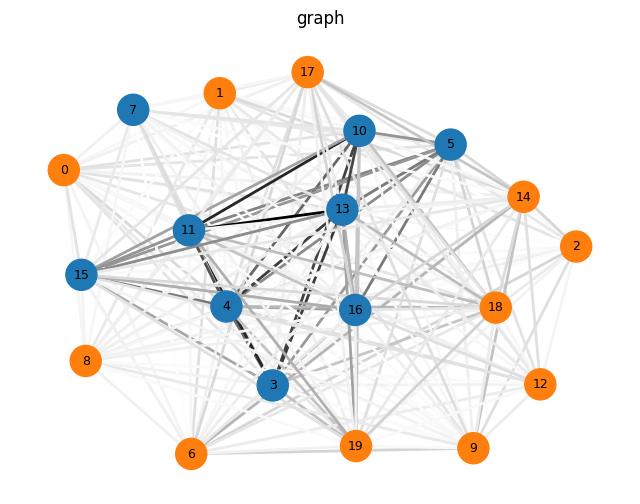

In [5]:
number_communities = 2

community_detection = CommunityDetection(adjacency_matrix=graph_adjacency, number_communities=number_communities)
communities = community_detection.run(solver_type="SIMULATED")

partitions = [np.where(communities == community)[0] for community in np.unique(communities)]

print(f"First community: {list([int(i) for i in partitions[0]])}")
print(f"Second community: {list([int(i) for i in partitions[1]])}")

draw_graph(graph=graph, labels=communities)

Following that we go through each detected community and treat it as its own smaller portfolio. For each community, it uses the returns and covariance of only the assets in that group to find the best allocation among them. Those inner community weights are stored in `lower_allocations`. Then we uses those weights to calculate how that optimized community portfolio would have performed each day, and store that daily return history in `community_daily_returns`.

In [6]:
lower_allocations = []
community_daily_returns = []

# optimize assets within each community first
for cluster in partitions:
    cluster_returns = returns.iloc[cluster].to_numpy()
    cluster_covariance = (covariance_matrix.iloc[cluster, cluster].to_numpy())

    inner_optimizer = AssetAllocation(returns=cluster_returns, covariance=cluster_covariance)
    inner_weights = inner_optimizer.run(solver_type="SIMULATED")

    lower_allocations.append(inner_weights)

    # return history of the actual optimized community portfolio
    cluster_return_history = (daily_returns.iloc[:, cluster].to_numpy() @ inner_weights)
    community_daily_returns.append(cluster_return_history)

print(lower_allocations)

[array([0.        , 0.        , 0.04761905, 0.61904762, 0.        ,
       0.12698413, 0.15873016, 0.03174603, 0.01587302]), array([0.28125 , 0.015625, 0.      , 0.      , 0.234375, 0.015625,
       0.234375, 0.      , 0.03125 , 0.03125 , 0.15625 ])]


Following that we take the daily return histories of all the optimized communities and combine them into one matrix, where each column represents one community portfolio and then calculate the annual return and covariance of those community portfolios, allowing the algorithm to treat each community as a single effective "asset" with that return and covariance. Then the upper optimizer uses those community chunks of returns and risks to decide how much of the total portfolio should be assigned to each community which are stored in `upper_weights`.

In [7]:
community_daily_returns = np.column_stack(community_daily_returns)
community_annual_returns = (community_daily_returns.mean(axis=0) * 252)
community_covariance = (np.cov(community_daily_returns, rowvar=False) * 252)

upper_optimizer = AssetAllocation(returns=community_annual_returns, covariance=community_covariance)
upper_weights = upper_optimizer.run(solver_type="SIMULATED")

print(upper_weights)

[0.703125 0.296875]


Then we just combine each community’s overall weight with the weights of the assets inside that community.

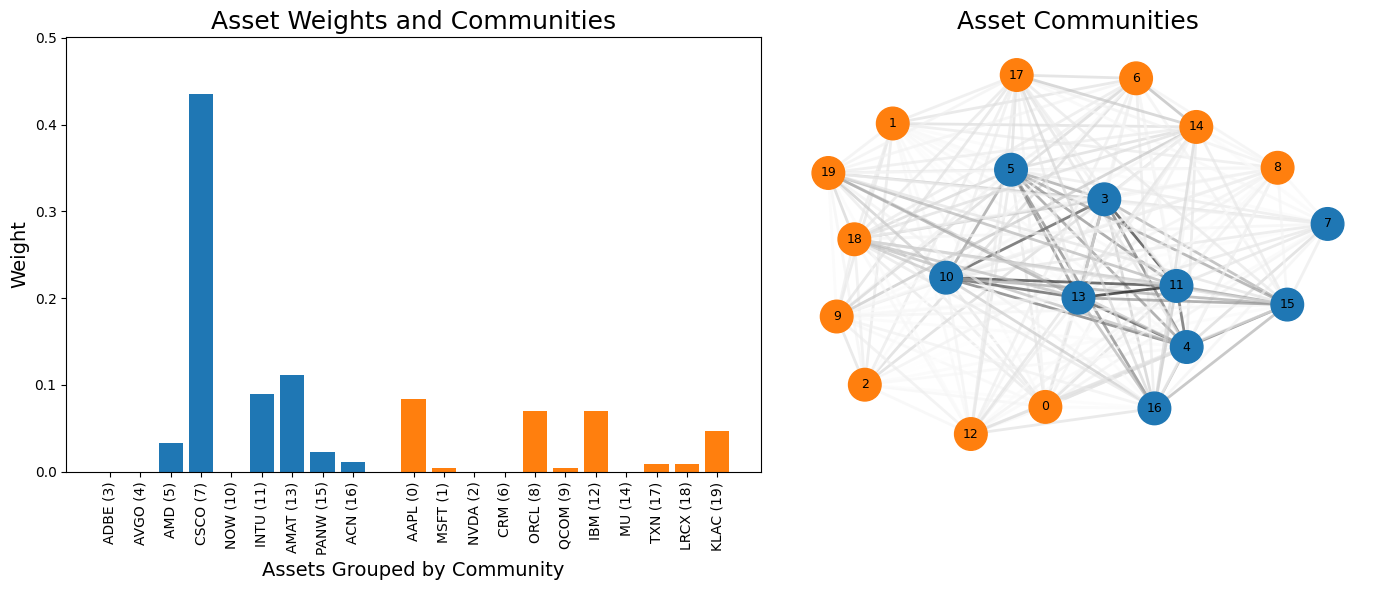

In [8]:
allocations = np.zeros(daily_returns.shape[1])

for community_weight, cluster, inner_weights in zip(upper_weights, partitions, lower_allocations):
    allocations[cluster] = (community_weight * inner_weights)

plot_allocations_and_communities(graph=graph, assets=assets, weights=allocations, communities=communities)